# Data Analysis - Project

Group Member:
| ID | Name |
|----------|:---------------------:|
| 22402742 | Nguyễn Phước Mai Bảo |
| 22302421 | Nguyễn Phúc Minh Châu |

In [2]:
# libraries
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc, f1_score, recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

df = pd.read_csv("heart_disease.csv")
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7,No,No,No
2,No,26.58,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,No,26.63,No,No,No,0,3,No,Female,65-69,Black,Yes,Yes,Very good,6,No,No,No
4995,No,NaN,Yes,No,No,0,0,No,Male,30-34,White,No,Yes,Very good,7,No,No,No
4996,No,31.89,Yes,Yes,No,0,2,No,Female,55-59,White,No,No,Very good,6,No,No,NaN
4997,No,27.26,Yes,No,No,0,0,Yes,Male,60-64,Other,Yes,Yes,Good,7,No,No,No


### Cleaning

In [3]:
# Universal cleaning — an toàn trước split (không phụ thuộc thống kê của data)
df = df.drop_duplicates()
df = df[df['PhysicalHealth'].between(0, 30)]
df = df[df['MentalHealth'].between(0, 30)]
df = df[df['SleepTime'].between(1, 24)]
df = df[df['BMI'].between(10, 60)]

# ===== SPLIT NGAY SAU CLEANING CƠ BẢN, TRƯỚC MỌI BƯỚC HỌC THỐNG KÊ =====
target = 'HeartDisease'   # lúc này chưa OHE nên target vẫn là cột gốc 'Yes'/'No'
X = df.drop(columns=[target])
y = df[target].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(3960, 17) (990, 17)


### One-hot Encoding

In [4]:
str_col = X_train.select_dtypes(include=['object', 'str']).columns
modes = X_train[str_col].mode().iloc[0]

X_train[str_col] = X_train[str_col].fillna(modes)
X_test[str_col] = X_test[str_col].fillna(modes)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore',
                    dtype=float, drop='if_binary')
ohe.fit(X_train[str_col])                       # fit CHỈ trên train

ohe_train = pd.DataFrame(ohe.transform(X_train[str_col]),
                          columns=ohe.get_feature_names_out(str_col), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[str_col]),
                         columns=ohe.get_feature_names_out(str_col), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=str_col), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=str_col), ohe_test], axis=1)

###  Imputer

In [5]:
imputer = IterativeImputer(random_state=42)
X_train_arr = imputer.fit_transform(X_train)     # học mô hình hồi quy CHỈ từ train
X_test_arr = imputer.transform(X_test)            # chỉ áp dụng, không học lại

X_train = pd.DataFrame(X_train_arr, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_arr, columns=X_test.columns, index=X_test.index)

### Outlier Detection

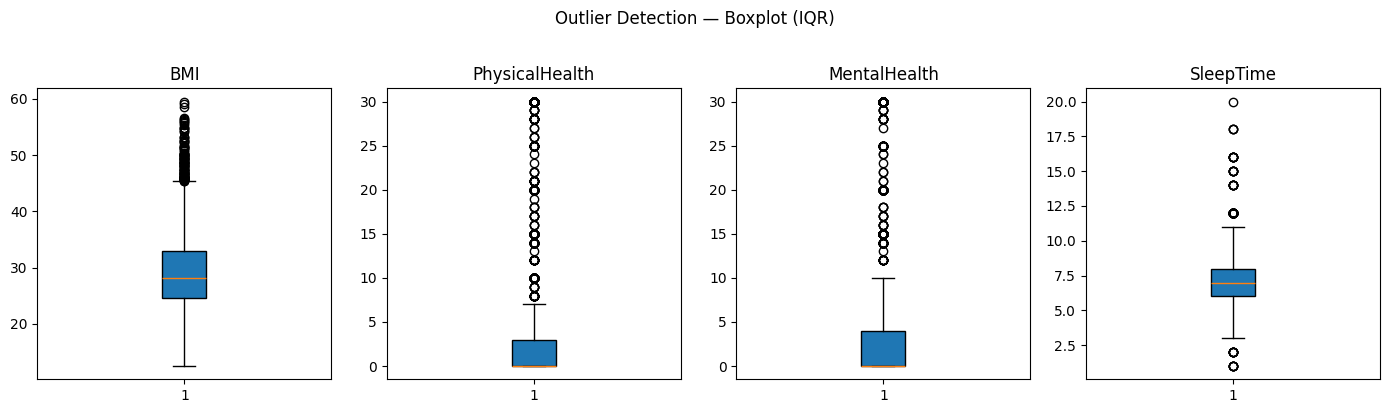

,BMI,PhysicalHealth,MentalHealth,SleepTime
0,12.02,-4.5,-6.0,3.0
1,45.46,7.5,10.0,11.0


In [6]:
# Chạy TRƯỚC bước train_test_split và StandardScaler
num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

num_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
bounds = {}
for col in num_cols:
    Q1, Q3 = X_train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)   # học từ TRAIN, dùng để báo cáo hoặc lọc cả hai nếu cần
# Boxplot
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col], patch_artist=True)
    ax.set_title(col)

plt.suptitle('Outlier Detection — Boxplot (IQR)', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(bounds)

### Data Scaling / Normalization

In [7]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Fearture Correlation

Số đặc trưng có |correlation| >= 0.1: 14 / 41
DiffWalking_Yes            0.224200
GenHealth_Poor             0.203297
Diabetic_Yes               0.202044
PhysicalHealth             0.196945
Diabetic_No               -0.190060
Stroke_Yes                 0.186155
KidneyDisease_Yes          0.134923
GenHealth_Very good       -0.130518
GenHealth_Excellent       -0.126028
GenHealth_Fair             0.123880
AgeCategory_80 or older    0.121822
Smoking_Yes                0.121665
AgeCategory_75-79          0.116558
PhysicalActivity_Yes      -0.114144
Name: HeartDisease_Yes, dtype: float64


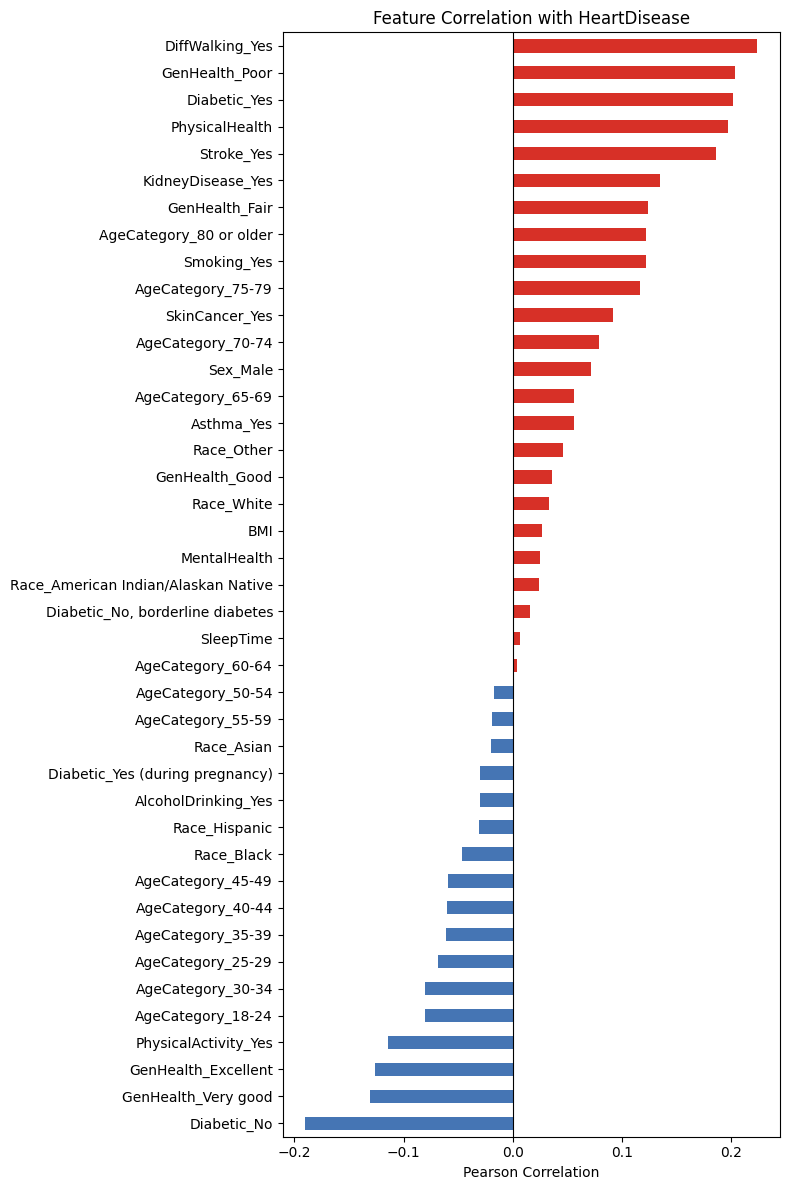

,Feature,Correlation
Rank,,
1,DiffWalking_Yes,0.224200
2,GenHealth_Poor,0.203297
3,Diabetic_Yes,0.202044
4,PhysicalHealth,0.196945
5,Diabetic_No,-0.190060
6,Stroke_Yes,0.186155
7,KidneyDisease_Yes,0.134923
8,GenHealth_Very good,-0.130518
9,GenHealth_Excellent,-0.126028


In [8]:
train_df = X_train.copy()
train_df['HeartDisease_Yes'] = y_train.values

target_corr = train_df.corr()['HeartDisease_Yes'].drop('HeartDisease_Yes').sort_values()

strong_corr = target_corr[target_corr.abs() >= 0.1].sort_values(key=abs, ascending=False)
selected_features = strong_corr.index.tolist()

print(f"Số đặc trưng có |correlation| >= {0.1}: {len(selected_features)} / {len(target_corr)}")
print(strong_corr)

plt.figure(figsize=(8, 12))
target_corr.plot(
    kind='barh',
    color=target_corr.map(lambda x: '#d73027' if x > 0 else '#4575b4')
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with HeartDisease')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

corr_target_df = target_corr.reset_index()
corr_target_df.columns = ['Feature', 'Correlation']
corr_target_df['Abs'] = corr_target_df['Correlation'].abs()
corr_target_df = corr_target_df.sort_values('Abs', ascending=False) \
                                .drop(columns='Abs') \
                                .reset_index(drop=True)
corr_target_df.index += 1
corr_target_df.index.name = 'Rank'

corr_target_df

### Feature Importance/ Feature Ranking

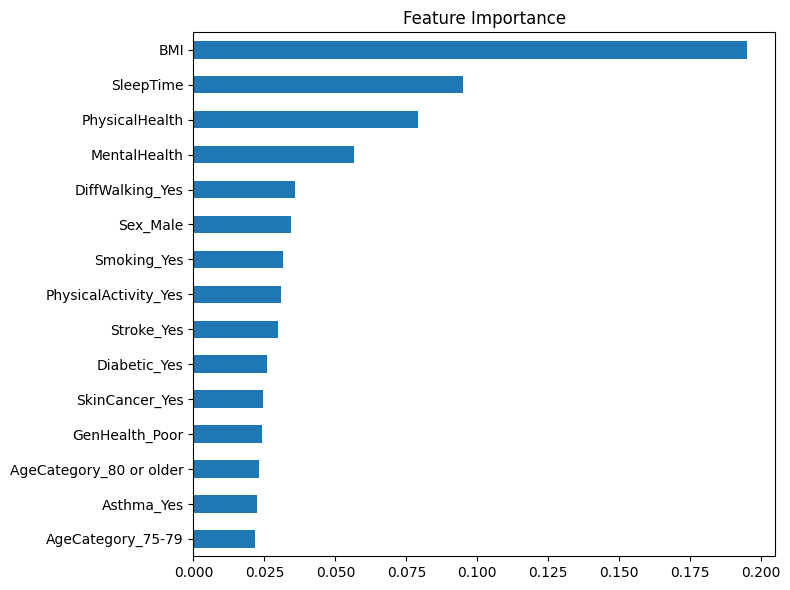

,Feature,Importance
0,BMI,0.195024
1,SleepTime,0.094828
2,PhysicalHealth,0.079171
3,MentalHealth,0.056450
4,DiffWalking_Yes,0.035817
5,Sex_Male,0.034476
6,Smoking_Yes,0.031380
7,PhysicalActivity_Yes,0.030875
8,Stroke_Yes,0.029840
9,Diabetic_Yes,0.026063


In [9]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#15 hàng đầu
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(15)

feat_imp.plot(kind='barh', figsize=(8, 6), title='Feature Importance')
plt.tight_layout()
plt.show()

feat_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feat_imp_df

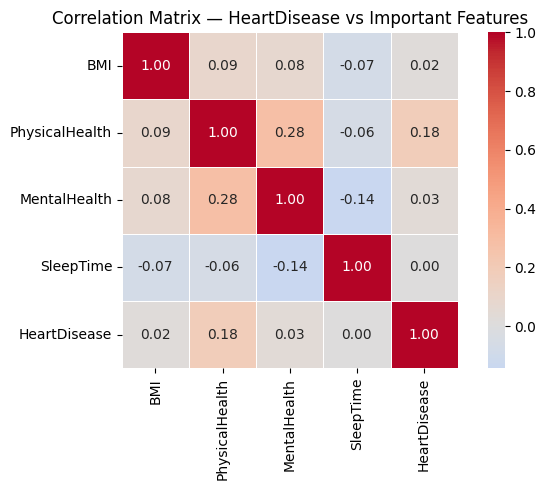

In [10]:
focus_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'HeartDisease']

df['HeartDisease'] = df['HeartDisease'].map({'Yes': 1, 'No': 0})

corr_matrix = df[focus_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Matrix — HeartDisease vs Important Features')
plt.tight_layout()
plt.show()

In [12]:
# Checking Imbalance in HeartDisease
print(df['HeartDisease'].value_counts(normalize=True))

HeartDisease
0    0.894141
1    0.105859
Name: proportion, dtype: float64


### Training Models

In [13]:
rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',  # ← tự động adjust weight theo ratio
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       885
           1       0.41      0.07      0.11       105

    accuracy                           0.89       990
   macro avg       0.66      0.53      0.53       990
weighted avg       0.85      0.89      0.85       990

ROC-AUC: 0.8034


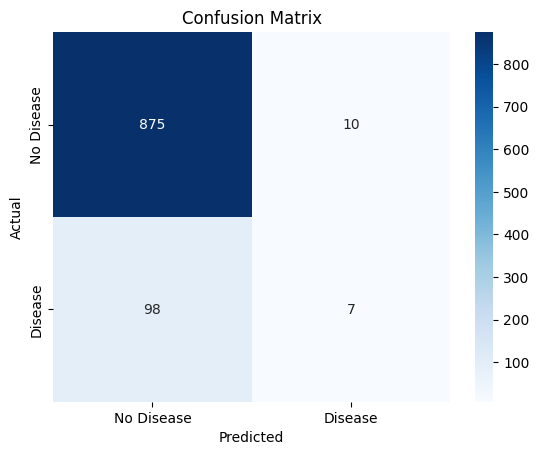

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0       0.98      0.51      0.67       885
           1       0.18      0.93      0.31       105

    accuracy                           0.55       990
   macro avg       0.58      0.72      0.49       990
weighted avg       0.90      0.55      0.63       990

ROC-AUC: 0.8283


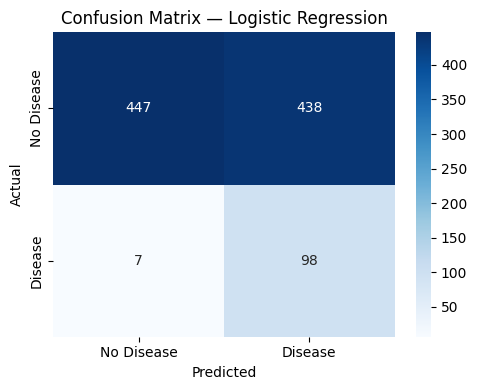

In [15]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= 0.25).astype(int)

# RF prob đã có
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.25).astype(int)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_auc = auc(rf_fpr, rf_tpr)
lr_auc = auc(lr_fpr, lr_tpr)

print("=" * 50)
print("Logistic Regression — Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC: {lr_auc:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease']
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

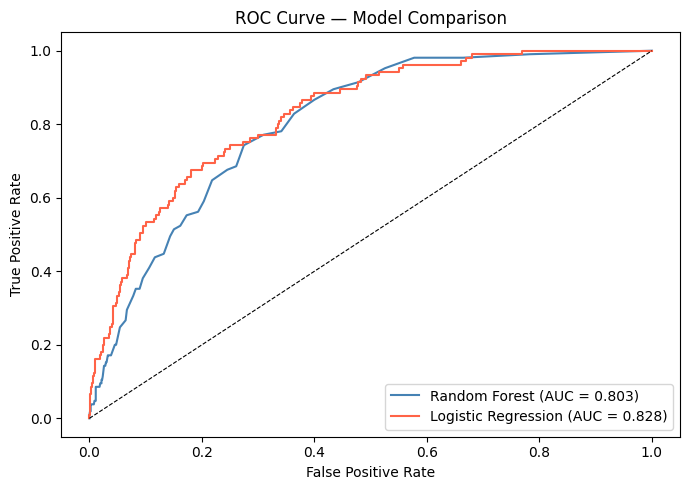

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.3f})', color='steelblue')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.3f})', color='tomato')
plt.plot([0,1], [0,1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

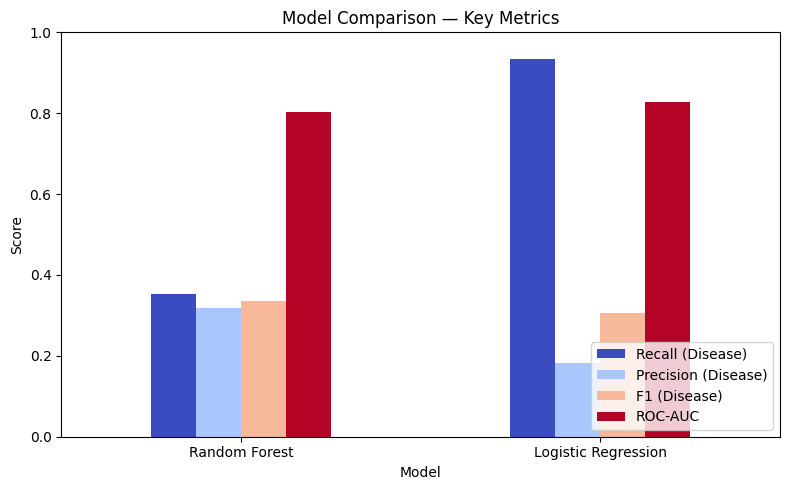

                     Recall (Disease)  Precision (Disease)  F1 (Disease)  \
Model                                                                      
Random Forest                   0.352                0.319         0.335   
Logistic Regression             0.933                0.183         0.306   

                     ROC-AUC  
Model                         
Random Forest          0.803  
Logistic Regression    0.828  


In [19]:
metrics = {
    'Model': ['Random Forest', 'Logistic Regression'],
    'Recall (Disease)': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, lr_pred)
    ],
    'Precision (Disease)': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, lr_pred)
    ],
    'F1 (Disease)': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, lr_pred)
    ],
    'ROC-AUC': [rf_auc, lr_auc]
}

metrics_df = pd.DataFrame(metrics).set_index('Model')

metrics_df.plot(kind='bar', figsize=(8, 5), rot=0, colormap='coolwarm')
plt.title('Model Comparison — Key Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(metrics_df.round(3))

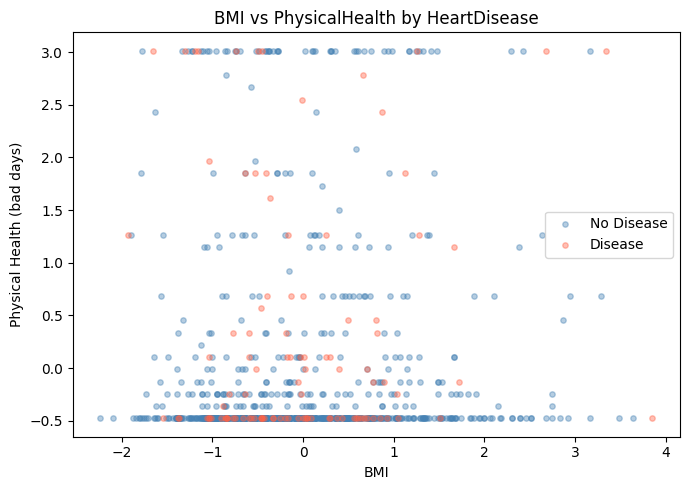

In [17]:
plt.figure(figsize=(7, 5))
colors = {0.0: 'steelblue', 1.0: 'tomato'}
labels = {0.0: 'No Disease', 1.0: 'Disease'}

for cls in [0.0, 1.0]:
    mask = y_test == cls
    plt.scatter(
        X_test.loc[mask, 'BMI'],
        X_test.loc[mask, 'PhysicalHealth'],
        c=colors[cls], label=labels[cls],
        alpha=0.4, s=15
    )

plt.xlabel('BMI')
plt.ylabel('Physical Health (bad days)')
plt.title('BMI vs PhysicalHealth by HeartDisease')
plt.legend()
plt.tight_layout()
plt.show()

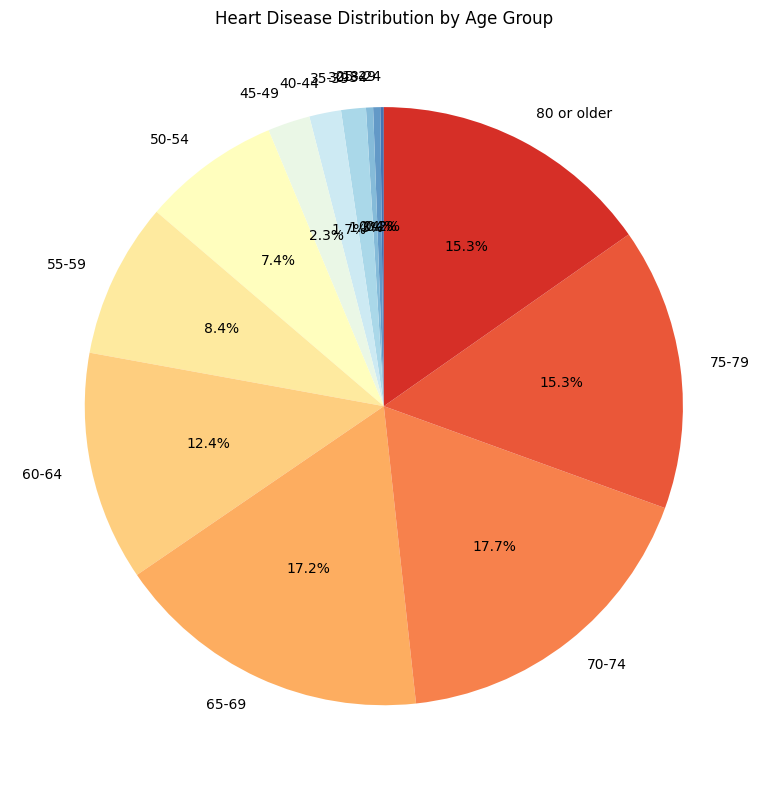

In [ ]:
full_encoded = pd.concat([X_train, X_test])
full_target = pd.concat([y_train, y_test])

age_cols = [col for col in full_encoded.columns if col.startswith('AgeCategory_')]
disease_df = full_encoded[full_target == 1.0]
age_counts = disease_df[age_cols].sum().sort_index()
age_counts.index = age_counts.index.str.replace('AgeCategory_', '')

plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90,
        colors=plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(age_counts))))
plt.title('Heart Disease Distribution by Age Group')
plt.tight_layout()
plt.show()